### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP2: Principal components regression in genetics

The goal of this TP session is to use genetic markers to predict the geographical origin of a set of indians from South, Central, and North America. We propose to build two regression linear models to predict the latitude and longitude of an individual based on its genetic markers. Because the number of markers (p = 5709) is larger than the number of samples (N = 494), the predictors of the regression model will be the outputs of a principal component analysis (PCA) performed on the genetic markers. A genetic marker is encoded 1 if the individual has a mutation, 0 elsewhere.

## ▶️ Exercise 1: Data visualization (1 point)

NB: To do this exercise you will have to install packages `geopandas` and `geodatasets`.

Download dataset `NAm2.txt` from [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP2/NAm2.txt). Each row of the dataset corresponds to an individual and the columns have explicit names. The third column contains the names of the tribes to which each individual pertains. Columns 7 and 8 contain the latitude and the longitude and from Column 9 onwards are genetic markers, which are encoded are 0 or 1. Run the code described below and explain how it works.

```
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()
```

/tmp/ipykernel_12249/767131013.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


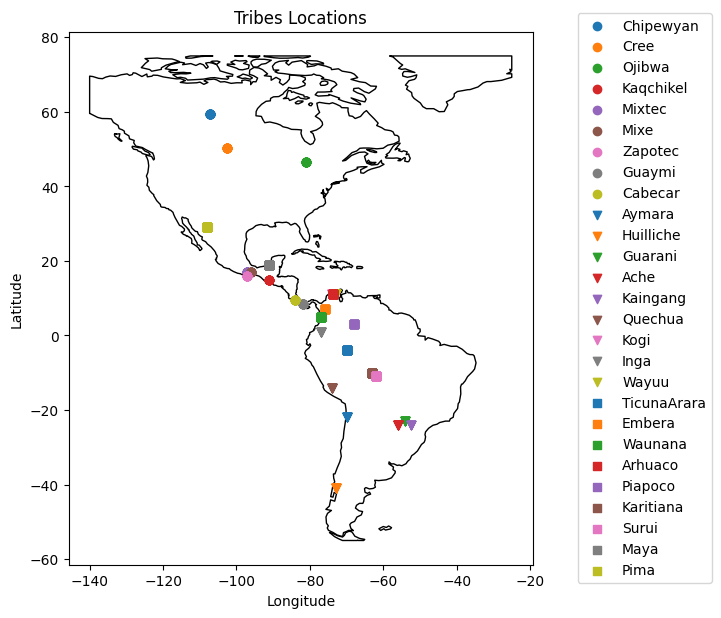

In [5]:
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()

The code visualizes the geographic distribution of Native American tribes by plotting each individual's location on a map of the Americas.

1. Preprocessing - Data loading and extraction :
It reads NAm2.txt as a space-delimited ```delimiter=' '``` file into a pandas DataFrame, then extracts the latitude (column 7), longitude (column 8), and tribe names (column 3, called Pop) for each individual.

2. GeoDataFrame Creation :
```gpd.GeoDataFrame``` wraps the regular DataFrame with geographic capabilities.  
```geometry=gpd.points_from_xy(longitude, latitude)``` converts the raw coordinate columns into proper geometry objects (points), enabling spatial operations and map plotting.

3. Map Rendering :
It loads a world land shapefile from the geodatasets package (naturalearth.land) and clips it to the bounding box [-140, -55, -25, 75] (lon_min, lon_max, lat_min, lat_max), which frames America.

4. Loop per tribe :
The loop iterates over each unique tribe in Pop. It assigns:
    a marker shape cycling through ['o', 'v', 's'] (circle, triangle, square) every 9 tribes via i//9
    a color cycling through 9 matplotlib default colors (colors_list[0-8]) via i%9.  
This combination handles up to 27 distinct tribes visually. Each tribe gets its own scatter layer and a legend entry.

## ▶️ Exercise 2: Multiple linear regression (2 points)

Using **only** the genetic markers as predictors, you will estimate a multiple linear regression model to predict the longitude of each individual.

You will proceed in several steps.

**(a)** First, try to estimate the coefficients of the multiple linear regression using the expression seen in class 

$$\hat{\beta} = (X^\top X)^{-1}X^\top y$$

You should proceed as we did in TP1 using `numpy.linalg.solve` to obtain the values of $\beta$. 

Did you run into any errors? What is going on? Relate your answer to the fact that $\text{rank}(X) < p$, where $X \in R^{N*p}$ is the data matrix.

In [6]:
import numpy as np

X = gdf.drop([gdf.columns[i] for i in range(9)] + ["geometry"], axis=1).to_numpy()
y = gdf['long'].to_numpy()

XtX = X.T @ X
Xty = X.T @ y

In [7]:
beta = np.linalg.solve(XtX, Xty)

LinAlgError: Singular matrix

np.linalg.solve raises a LinAlgError : Singular matrix

np.linalg.solve(A, b) requires A to be invertible !

Here :
$X \in \mathbb{R}^{N×p}$ with $N = 494$ individuals and $p = 5709$ markers
Since $N << p$
By the rank inequality: 
$$
rank(X) ≤ min(N, p) = p
$$

Therefore: 
$$
rank(XᵀX) = rank(X) ≤ p < n
$$

So $XᵀX \in \mathbb{R}^{p×p}$ is not full rank, it is singular, so it has no inverse.

**(b)** Use function `numpy.linalg.lstsq` to estimate the coefficients (it may take a few seconds to get a result). 

And now? Did you get any errors? Why is that? 

Relate your answer to the difference between functions `numpy.linalg.solve` and `numpy.linalg.lstsq`.

You can check the documention for both functions as well as [this](https://netlib.org/lapack/lug/node27.html) link for more information.

In [8]:
beta_lstsq, residuals, rank, s = np.linalg.lstsq(XtX, Xty)

print(f"Shape of XtX:    {XtX.shape}")
print(f"Rank: {rank}")
print(f"beta shape:    {beta_lstsq.shape}")

Shape of XtX:    (5708, 5708)
Rank: 494
beta shape:    (5708,)


`numpy.linalg.lstsq` works to compute the $\beta$. Instead of computing the inverse, it computes a minimum norm solution of an underdetermined system.  
It minimises $\| X \beta - y \|_2$ and, among all minimisers, returns the one with smallest $\| \beta \|_2$. This succeeds regardless of rank deficiency

 **(c)** We will now use `sklearn` to do our linear regression with the help of class `sklearn.linear_model.LinearRegression` whose documentation is available [here](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LinearRegression.html). Note that every estimator from `sklearn` has a `fit` and a `predict` method, which are used to calculate coefficients and predict values (see [here](https://scikit-learn.org/stable/getting_started.html#fitting-and-predicting-estimator-basics) for more info). In our current case, we can do:

```
# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)
```

You should not run into errors now, since `sklearn` also uses `lstsq` to solve the normal equations, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L682) (though it uses the `scipy` implementation instead of the `numpy` for "historical" reasons). Check the values of the estimated coefficients stored as an attribute in `lr.coef_`, are they the same as the ones obtained in item **(b)**? Probably not. This is because `sklearn` re-centers the predictors before estimating the coefficients of the linear regression, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L622). What would be a practical reason for doing such re-centering systematically? Hint: it has to do with how to interpret the intercept of the model. 

In [9]:
from sklearn.linear_model import LinearRegression

predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
beta_sklearn = lr.coef_

print('Value of beta sklearn :', beta_sklearn)
print('Value of beta lstsq :', beta_lstsq)

Value of beta sklearn : [-0.03940988 -0.0245272   0.01089763 ...  0.04804479 -0.08985062
  0.01903025]
Value of beta lstsq : [-0.01940642  0.01111643 -0.01234665 ... -0.21731854 -0.10210132
  0.01813647]


The estimated coefficients obtained through sckit-learn and lstsq are not the same.  
Scikit-learn re-centers systematically X and y, it resolves :
$$
\hat y - \bar y = (X - \bar X)^\top \hat \beta
$$

Without centering, the intercept corresponds to an individual with all-zero markers, which is not a meaningful reference point. By centring, the intercept equals the mean response $\bar y$ evaluated at the mean predictor $\bar X$.

## ▶️ Exercise 3: Principal components analysis (5 points)

**(a)** Explain in a few words the main concepts and ideas underlying the principal component analysis (PCA). You should include both the geometric and statistical interpretations of PCA.

A first idea is to resume the data i the Gram matrix $\sum = \frac{1}{n} X ^\top X$ by minimizing the distance between the covariates and their projections on the new subspace.  

Let $V$ be an orthogonal basis of this subspace such that the weights $(v_j)_{j=1}^{K}$ satisfy this condition. The projection of the i-th row $X_i$,· can be written $V V^\top Xi$,· . This leads to finding $V \in \mathbb{R}^{p ×K}$ minimizing $\| X - X V V^\top \|_F^2 $ (the Frobenius norm)
It is known that the solution is the matrix of the eigenvectors of $X ^\top X$ associated to the highest eigenvalues.

This corresponds to applying principal component analysis (PCA). The first principal axis $v_11$ is formed as a linear combination of the original covariates that explains the most variance,
$$ 
w_1^{\text{PCA}} = \arg\max_{w \in \mathbb{R}^p, \, \|w\| = 1} \| X w \|
$$

Example in $\mathbb{R}²$

/tmp/ipykernel_12249/2911761687.py:9: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  pts = np.random.multivariate_normal(mean, cov, N)


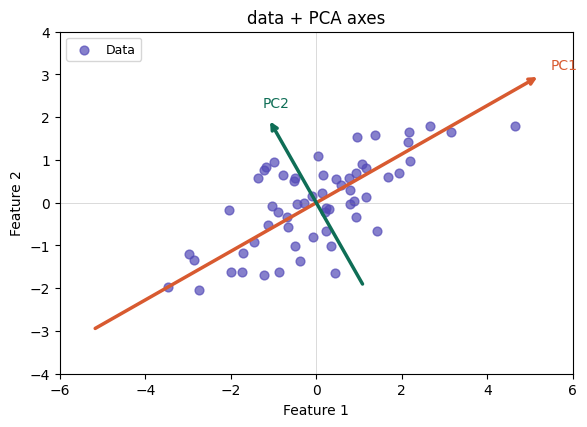

In [12]:
np.random.seed(42)
N = 60

mean = [0, 0]

cov = [[3.0, 1.8],
       [1.8, 0.5]]

pts = np.random.multivariate_normal(mean, cov, N)
pts = pts - pts.mean(axis=0)

U, S, Vt = np.linalg.svd(pts, full_matrices=False)
eigenvalues = S**2 / N
eigenvectors = Vt
total_var = eigenvalues.sum()

# Colors for the principal components
colors_pc = ['#D85A30', '#0F6E56']


fig, ax = plt.subplots(figsize=(6, 5))  # un seul panel → (fig, ax)

# Plot the original data points
ax.scatter(pts[:, 0], pts[:, 1], alpha=0.7, color='#534AB7', s=40, label='Data')
ax.axhline(0, color='gray', lw=0.5, alpha=0.4)
ax.axvline(0, color='gray', lw=0.5, alpha=0.4)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_aspect('equal')
ax.set_xlim(-6, 6)
ax.set_ylim(-4, 4)

# Plot the principal component axes
for i, (vec, val) in enumerate(zip(eigenvectors, eigenvalues)):
       length = np.sqrt(val) * 3.5
       pct = val / total_var * 100
       ax.annotate('', xy=vec*length, xytext=-vec*length,
              arrowprops=dict(arrowstyle='->', color=colors_pc[i], lw=2.5))
       ax.text(*(vec*length + vec*0.3), f'PC{i+1}',
              color=colors_pc[i])
ax.set_title('data + PCA axes')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

The figure shows the centered data cloud along with the two principal axes derived from PCA. 

PC1 (in orange) points in the direction of maximum variance, it is the axis along which the points are most spread out.

PC2 (in green) is orthogonal to PC1 and captures the remaining variance. 

The PCA axes are aligned with the ellipse of the data cloud: PC1 follows the major axis, PC2 the minor axis.

**(b)** Use the estimator defined in `sklearn.decomposition.PCA` to do a PCA on the dataset. Plot the first two dimensions of the projected data points on a scatterplot. The scattered points should have different markers and colors depending on which tribe they belong to. You can use the same color/marker style from **Exercise 2** or propose a new one.

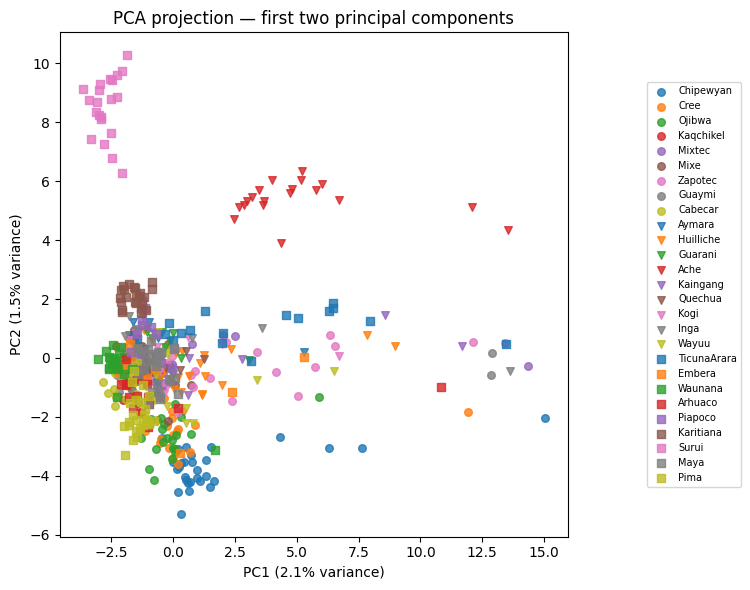

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

predictors = df.columns[8:]
X = df[predictors].values

gdf_pca = pca.fit_transform(X)

# Plot
tribes = gdf['Pop'].unique()

fig, ax = plt.subplots(figsize=(8, 6))
for i, tribe in enumerate(tribes):
    mask = gdf['Pop'] == tribe
    ax.scatter(gdf_pca[mask, 0], gdf_pca[mask, 1],
               marker=marker_list[i // 9],
               color=colors_list[i % 9],
               label=tribe, s=30, alpha=0.8)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('PCA projection - first two principal components')
ax.legend(loc='center right', bbox_to_anchor=(1.35, 0.5), fontsize=7)
plt.tight_layout()
plt.show()

**(c)** Remember from our class that the results of PCA are affected when pre-processing transformations are applied to the data. We will illustrate this using `sklearn.preprocessing.StandardScaler` as per:
```
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)
```
Redo the 2D scatter plot from item **(b)** on the normalized version of the datast. How does it compare to your previous plot?

cumulative percentage of variance (PC1+PC2): 3.39%


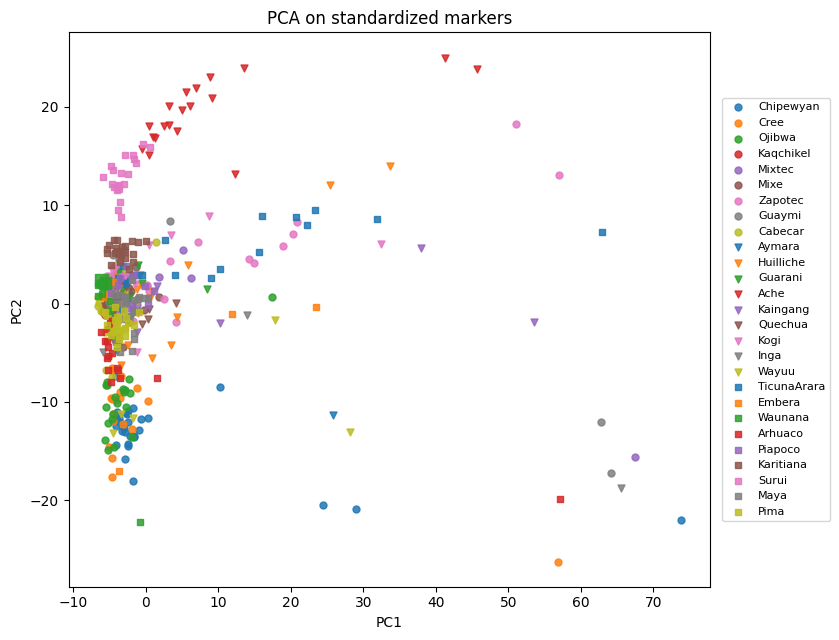

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Normalize + PCA
X_std = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=0)
scores_std = pca.fit_transform(X_std)

print(f"cumulative percentage of variance (PC1+PC2): {pca.explained_variance_ratio_.sum()*100:.2f}%")

fig, ax = plt.subplots(figsize=(8.5, 6.5))


for i, tribe in enumerate(df['Pop'].unique()):
    mask = df['Pop'] == tribe
    ax.scatter(
        scores_std[mask, 0],
        scores_std[mask, 1],
        marker=marker_list[i // 9],
        color=colors_list[i % 9],
        label=tribe,
        s=25,
        alpha=0.85,
    )

ax.set_title('PCA on standardized markers')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

Compared with the previous plot (PCA without standardization), the standardized PCA plot is globally very similar: the same broad population structure is preserved, with only moderate shifts in point positions and axis orientation. In other words, standardization slightly rebalances the contribution of markers but does not fundamentally change the clustering pattern. This is expected here because the genetic markers are already on comparable scales (mostly binary 0/1).

**(d)** Given the results in **(b)** and **(c)**, what can you conclude regarding the necessity of standardizing the data points for the dataset consider in this TP?

Answer : From (b) and (c), we conclude that standardization is not strictly mandatory for this dataset, since the global PCA structure changes only slightly after scaling. Here, because markers are already on similar scales, the impact is limited.

**(e)** Which percentage of variance is captured by the first two principal components? How many principal components would you keep if you would like to represent the genetic markers using a minimal number of principal components? To help answering this question, you can use a plot showing the cumulative percentage of variance as a function of the number of principal components.

Answer : The first two principal components explain only a small fraction of the total variance (about 3.57% without standardization; about 3.39% after standardization).

Using the cumulative explained-variance curve, a reasonable minimal choice is to keep enough components to reach a target such as 95% variance:

about 410 PCs (unscaled PCA),
about 425 PCs (standardized PCA).
So I would keep roughly ~420 components.

9.321910650036808e-20
PC1+PC2 raw: 3.57%
PC1+PC2 std: 3.39%
Components for 95% (raw): 410
Components for 95% (std): 425


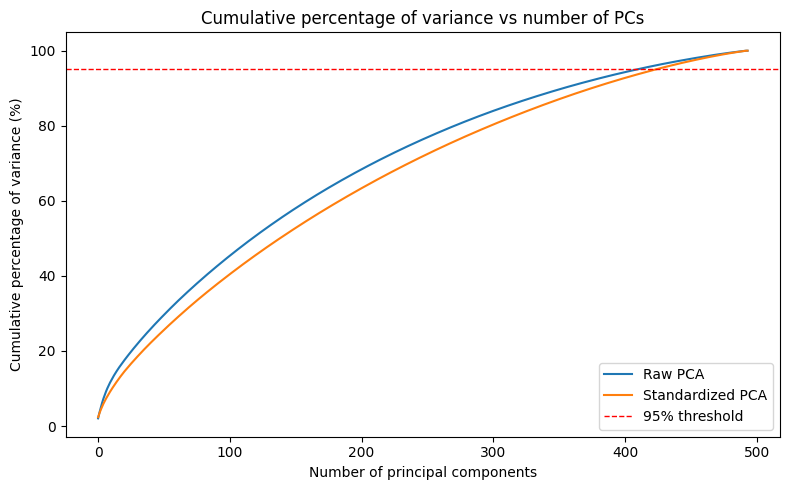

In [ ]:
# No standardization
pca_raw = PCA().fit(X)
cum_raw = np.cumsum(pca_raw.explained_variance_ratio_) * 100

# With standardization
X_std = StandardScaler().fit_transform(X)
pca_std = PCA().fit(X_std)
cum_std = np.cumsum(pca_std.explained_variance_ratio_) * 100

# Nb de composantes pour 95%
k95_raw = np.searchsorted(cum_raw, 95) + 1
k95_std = np.searchsorted(cum_std, 95) + 1

print(f"PC1+PC2 raw: {cum_raw[1]:.2f}%")
print(f"PC1+PC2 std: {cum_std[1]:.2f}%")
print(f"Components for 95% (raw): {k95_raw}")
print(f"Components for 95% (std): {k95_std}")

# Plot cumul variance
plt.figure(figsize=(8,5))
plt.plot(cum_raw, label='Raw PCA')
plt.plot(cum_std, label='Standardized PCA')
plt.axhline(95, color='red', linestyle='--', linewidth=1, label='95% threshold')
plt.xlabel('Number of principal components')
plt.ylabel('Cumulative percentage of variance (%)')
plt.title('Cumulative percentage of variance vs number of PCs')
plt.legend()
plt.tight_layout()
plt.show()


## ▶️ Exercise 4: Principal components regression (4 points)

**(a)** Predict the latitude and the longitude of all points from the dataset using the scores of the first 250 PCA axes. Plot the predicted spatial coordinates using the same style and structure from **Exercise 1** and compare the results from each plot. What can you conclude? Does the new map illustrate somehow too optimistically (or too pessimistically) the ability to find geographical origin of individuals outside the database from its genetic markers? Justify your answer.

In [16]:
pca = PCA(n_components=250)
X_red = pca.fit_transform(X_std)

y_long = df['long']
y_lat = df['lat']

lr_lat = LinearRegression()
lr_lon = LinearRegression()

lr_lat.fit(X_red, y_lat)
lr_lon.fit(X_red, y_long)


lat_pred = lr_lat.predict(X_red)
lon_pred = lr_lon.predict(X_red)


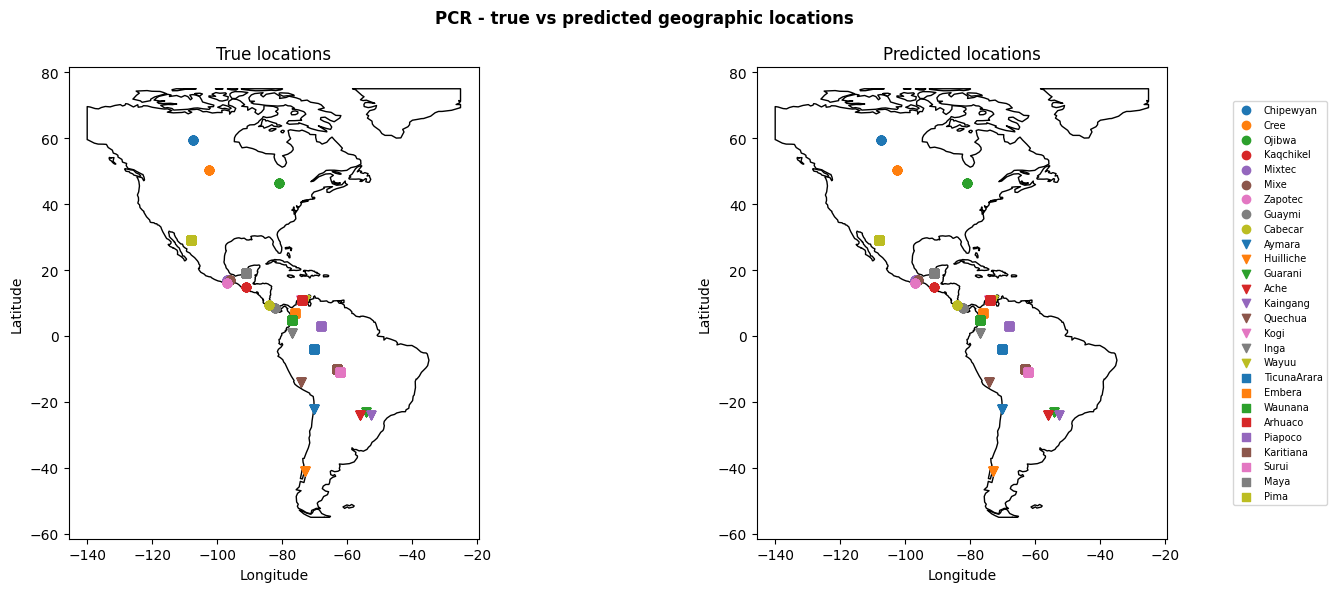

In [17]:
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf_pred = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(lon_pred, lat_pred))
gdf_real = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))


world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)


plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)

world.clip([-140, -55, -25, 75]).plot(ax=axes[0], color='white', edgecolor='black')
for i, tribe in enumerate(gdf_real['Pop'].unique()):
    members_tribe = gdf_real[gdf_real['Pop'] == tribe]
    axes[0].scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
axes[0].set_title('True locations')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

world.clip([-140, -55, -25, 75]).plot(ax=axes[1], color='white', edgecolor='black')
for i, tribe in enumerate(gdf_pred['Pop'].unique()):
    members_tribe = gdf_pred[gdf_pred['Pop'] == tribe]
    axes[1].scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
axes[1].set_title('Predicted locations')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

axes[1].legend(loc='center right', bbox_to_anchor=(1.4, 0.5), fontsize=7)
plt.suptitle('PCR - true vs predicted geographic locations', fontweight='bold')
plt.tight_layout()
plt.show()


The predicted locations are visually very close to the true ones for most tribes.  
However, this evaluation is done on the training data itself (the same X used to fit the model), which means the model has not been tested on unseen individuals. The high apparent accuracy is therefore likely to reflect overfitting rather than true generalisation ability, since with K=250 components and only N=494 individuals the regression model has a very large number of free parameters relative to the sample size. 
A proper evaluation would require cross-validation or an outside test set.

**(b)** Quantify the error of the linear regression model using the mean distance between real and predicted coordinates. Beware to use `sklearn.metrics.pairwise.haversine_distances` so to correctly measure the distances between points so to take into account the curvature of the Earth. Your answer should be given in kilometers.

In [18]:
from sklearn.metrics.pairwise import haversine_distances

true_coords = np.radians(np.column_stack([y_lat, y_long]))
pred_coords = np.radians(np.column_stack([lat_pred, lon_pred]))

# only the coef in the diagonal are the 
# distances between true and predicted for each individual,
# the rest are distances between different individuals
distances = np.diag(haversine_distances(true_coords, pred_coords)) * 6371


mean_dist = distances.mean()
std_dist  = distances.std()

print(f"Mean distance: {mean_dist:.1f} km")
print(f"Std  distance: {std_dist:.1f} km")

Mean distance: 485.7 km
Std  distance: 366.3 km


This error is computed on the training data, so it represents an optimistic lower bound on the true generalisation error.  
Despite this, the error is still large, which is somewhat surprising given the high R² observed earlier.  
The standard deviation of 390 km is also large, suggesting that prediction quality varies substantially across individuals, some tribes are predicted very accurately while others are far off.

## ▶️ Exercise 5: PCR and cross-validation (6 points)

Our goal now is to build the best model to predict individual geographical coordinates. 

For this, you will run a linear regression to predict latitudes and longitudes. Note that `sklearn.linear_model.LinearRegression` can naturally handle the fact of having two sets of coefficients. We will use ten-fold cross-validation to helps us choose the number of principal axes that we should keep. You should report the errors in terms of kilometers as done in **Exercise 4(b)**.

**(a)** Recall in a few words the principle of cross-validation. Explain why this procedure is useful when building a predictive model. Your answer should mention different strategies to handle datasets in which the samples are not IID.

The cross-validation consists of splitting the dataset into k different folds and each time we use k-1 of them for training the model and one for testing. At the end we compute the mean the obtained errors.      

This procedure is useful when building a predictive model because it gives a more realistic approximation of the model's performance on testing data and it helps detect overfitting and select a model that generalises better.

To handle samples in which datasets are not IID, different strategies exist. GroupKFold ensures that all data from the same group is kept either entirely in training set or entirely in  the test set, which better simulates predictions on unseen data. ShuffleSplit randomly shuffles the data before splitting, which at least breaks the ordering of the rows.

**(b)** Based on the structure of the dataset being used, such as the different countries of the individuals and the order in which the rows of the dataframe are provided, explain which choice of cross-validation iterator from [here](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators) seems the most adequate for our context.

Given the structure of the dataset, where individuals are grouped by tribe and country and rows are ordered by group, a standard KFold iterator would produce folds that are geographically homogeneous, leading to an overly optimistic evaluation. Since individuals from the same tribe share very similar genetic markers, we need to ensure that no group is split across train and test sets. We therefore use GroupKFold with countries as groups, which guarantees that all individuals from a given country appear either entirely in the train set or entirely in the test set. This best simulates the realistic scenario of predicting the geographical origin of individuals from a population never seen during training.

**(c)** We first assess the quality of the PCR fit for `n_components=4`. Note that you should be careful in avoiding [data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage) problems when doing the PCA followed by a multiple linear regression. You should use the pipeline interface from scikit-learn with `sklearn.pipeline.make_pipeline` to facilitate your task. Be sure to evaluate the errors as done in **Exercise 4(b)**.

In [19]:
import numpy as np
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.metrics import make_scorer
from sklearn.metrics.pairwise import haversine_distances

#data
df = pd.read_csv('NAm2.txt', delimiter=' ')

predictors = df.columns[8:]
X = df[predictors].values
y = df[['lat', 'long']].values
groups = df['Country']

#scorer haversine in km
def haversine_km(y_true, y_pred):
    y_true_rad = np.radians(y_true)
    y_pred_rad = np.radians(y_pred)
    distances = haversine_distances(y_true_rad, y_pred_rad)
    return np.mean(np.diag(distances)) * 6371

scorer = make_scorer(haversine_km, greater_is_better=False)

#pipeline PCA + regression
pipe = make_pipeline(PCA(n_components=4), LinearRegression())

#cross-validation
cv = GroupKFold(n_splits=10)

results = cross_validate(
    pipe, X, y,
    cv=cv,
    groups=groups,
    scoring=scorer,
    return_train_score=True
)

#résultats
print(f"Test error  (km) : {-results['test_score'].mean():.1f} ± {results['test_score'].std():.1f}")
print(f"Train error (km) : {-results['train_score'].mean():.1f} ± {results['train_score'].std():.1f}")

Test error  (km) : 2779.7 ± 1697.7
Train error (km) : 1781.7 ± 147.0


**(d)** Repeat the analysis from item **(b)** but changing `n_components` between 2 and 440 in steps of 10. Plot the mean training and test errors versus the number of principal components. Attention, the errors should be given in kilometers.

n=2 done
n=12 done
n=22 done
n=32 done
n=42 done
n=52 done
n=62 done
n=72 done
n=82 done
n=92 done
n=102 done
n=112 done
n=122 done
n=132 done
n=142 done
n=152 done
n=162 done
n=172 done
n=182 done
n=192 done
n=202 done
n=212 done
n=222 done
n=232 done
n=242 done
n=252 done
n=262 done
n=272 done
n=282 done
n=292 done
n=302 done
n=312 done
n=322 done
n=332 done
n=342 done
n=352 done
n=362 done


/home/hiba/reports_tp/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
1 fits failed out of a total of 10.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/home/hiba/reports_tp/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/hiba/reports_tp/.venv/lib/python3.13/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/hiba/reports_tp/.venv/lib/python3.13/site-packages/sklearn/pipeli

n=372 done


/home/hiba/reports_tp/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
1 fits failed out of a total of 10.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/home/hiba/reports_tp/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/hiba/reports_tp/.venv/lib/python3.13/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/hiba/reports_tp/.venv/lib/python3.13/site-packages/sklearn/pipeli

n=382 done


/home/hiba/reports_tp/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
2 fits failed out of a total of 10.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/home/hiba/reports_tp/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/hiba/reports_tp/.venv/lib/python3.13/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/hiba/reports_tp/.venv/lib/python3.13/site-packages/sklearn/pipeli

n=392 done


/home/hiba/reports_tp/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
2 fits failed out of a total of 10.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/home/hiba/reports_tp/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/hiba/reports_tp/.venv/lib/python3.13/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/hiba/reports_tp/.venv/lib/python3.13/site-packages/sklearn/pipeli

n=402 done


/home/hiba/reports_tp/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
2 fits failed out of a total of 10.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/home/hiba/reports_tp/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/hiba/reports_tp/.venv/lib/python3.13/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/hiba/reports_tp/.venv/lib/python3.13/site-packages/sklearn/pipeli

n=412 done


/home/hiba/reports_tp/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
2 fits failed out of a total of 10.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/home/hiba/reports_tp/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/hiba/reports_tp/.venv/lib/python3.13/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/hiba/reports_tp/.venv/lib/python3.13/site-packages/sklearn/pipeli

n=422 done
n=432 done


/home/hiba/reports_tp/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
3 fits failed out of a total of 10.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/home/hiba/reports_tp/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/hiba/reports_tp/.venv/lib/python3.13/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/hiba/reports_tp/.venv/lib/python3.13/site-packages/sklearn/pipeli

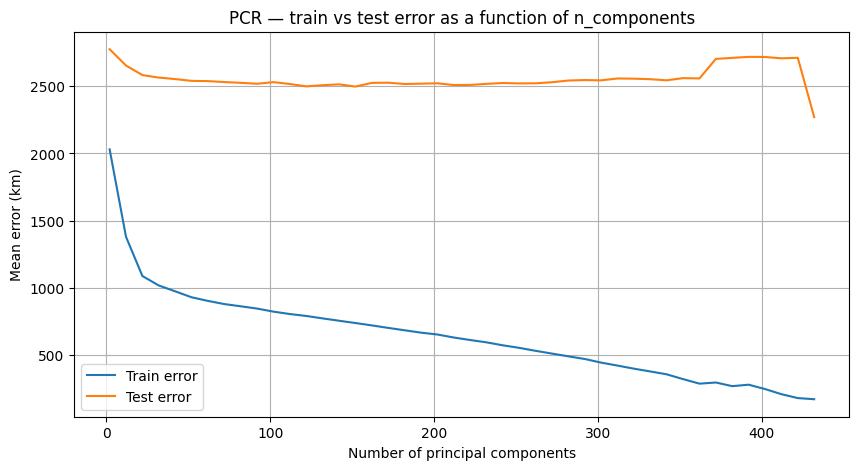

Best n_components : 432
Test error  (km)  : 2270.4
Train error (km)  : 170.3


In [20]:
import matplotlib.pyplot as plt

n_components_list = list(range(2, 441, 10))
train_errors = []
test_errors = []

for n in n_components_list:
    pipe = make_pipeline(
        PCA(n_components=n, svd_solver='full'),
        LinearRegression()
    )
    cv = GroupKFold(n_splits=10)
    
    results = cross_validate(
        pipe, X, y,
        cv=cv,
        groups=groups,
        scoring=scorer,
        return_train_score=True
    )
    
    train_errors.append(-np.nanmean(results['train_score']))
    test_errors.append(-np.nanmean(results['test_score']))
    print(f"n={n} done")

#plot
plt.figure(figsize=(10, 5))
plt.plot(n_components_list, train_errors, label='Train error')
plt.plot(n_components_list, test_errors,  label='Test error')
plt.xlabel('Number of principal components')
plt.ylabel('Mean error (km)')
plt.title('PCR — train vs test error as a function of n_components')
plt.legend()
plt.grid(True)
plt.show()

#best model
best_idx = test_errors.index(min(test_errors))
best_n   = n_components_list[best_idx]
print(f"Best n_components : {best_n}")
print(f"Test error  (km)  : {test_errors[best_idx]:.1f}")
print(f"Train error (km)  : {train_errors[best_idx]:.1f}")

**(e)** Which model would you keep? What is the prediction error for this model? Compare it with its corresponding training error. Plot the predicted coordinates on a map as in **Exercise 4(a)**. What can you conclude?

## ▶️ Exercise 6: Conclusion (2 points)

Propose a conclusion to your study. You can write a paragraph about the quality of predictors versus the number of factors, possible improvements to the approach (for instance, showing what happens when using [partial least squares](https://scikit-learn.org/1.5/auto_examples/cross_decomposition/plot_pcr_vs_pls.html) instead of PCR), comment on the performance of the regression in predictions for each country separately, etc. Note that we expect a thorough presentation of the final predictive model as well as an interpretation of it, not simply a bunch of `python` code lines.